<img src="https://drive.google.com/uc?export=view&id=1Y-EIpLOigI9ycCOZRrRSFzAfuN9cxhqT" alt="Hobot Academy" width="300" height="300">

<h1 align="center"><font size="14">Hands-On Machine Learning</font></h1>
<h3 align="center"><font size="7">Session21: Decision Tree with scikit-learn</font></h3>
<h3 align="center">Zahra Amini</h3>

# Part 01

# Decision Tree Classifier 

# 0. Import libraries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split

import category_encoders
import category_encoders as ce

from sklearn.tree import DecisionTreeClassifier

from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score

from sklearn import tree

from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report

from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import plot_confusion_matrix

In [19]:
pip install category_encoders

     -------------------------------------- 72.4/72.4 kB 440.8 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [20]:
import warnings

warnings.filterwarnings('ignore')

# 1. Read data

In [2]:
path = 'car_evaluation.csv'

df = pd.read_csv(path, header=None)

# 2. Exploratory data analysis

In [3]:
df.shape

(1728, 7)

In [4]:
df.head()

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [5]:
# Rename column names

col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']


df.columns = col_names

col_names

['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

In [6]:
# let's again preview the dataset

df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [8]:
df['class'].unique()

array(['unacc', 'acc', 'vgood', 'good'], dtype=object)

In [9]:
df['class'].value_counts()

unacc    1210
acc       384
good       69
vgood      65
Name: class, dtype: int64

### Missing values in variables

In [10]:
# check missing values in variables

df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

# 3. X, y

In [11]:
X = df.drop(['class'], axis=1)

y = df['class']

In [12]:
X.shape

(1728, 6)

# 4. train test split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [14]:
X_train.shape, X_test.shape

((1209, 6), (519, 6))

# 5. Preprocessing

In [15]:
X_train.dtypes

buying      object
maint       object
doors       object
persons     object
lug_boot    object
safety      object
dtype: object

In [16]:
X.columns

Index(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'], dtype='object')

### Encode categorical variables

In [23]:
encoder = ce.OrdinalEncoder(cols=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety'])

In [24]:
X_train = encoder.fit_transform(X_train)

In [25]:
X_test = encoder.transform(X_test)

In [26]:
X_train

,buying,maint,doors,persons,lug_boot,safety
1178,1,1,1,1,1,1
585,2,2,2,2,2,2
1552,3,1,2,1,3,3
1169,1,1,1,3,1,1
1033,1,2,3,3,1,3
...,...,...,...,...,...,...
1130,1,1,2,2,3,1
1294,1,4,1,2,1,3
860,2,4,1,2,3,1
1459,3,2,3,3,2,3


# 6. Decision Tree Classifier with criterion gini index

In [48]:
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth = 3, random_state=42)

In [49]:
clf_gini.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

### Predict the Test set results with criterion gini index

In [50]:
y_pred_gini = clf_gini.predict(X_test)

### Check accuracy score with criterion gini index

In [51]:
accuracy_score(y_test, y_pred_gini)

0.7591522157996147

### Compare the train-set and test-set accuracy

In [52]:
y_pred_train = clf_gini.predict(X_train)

### Check for overfitting and underfitting

In [53]:
accuracy_score(y_train, y_pred_train)

0.7766749379652605

### feature importances

In [54]:
clf_gini.feature_importances_

array([0.04933822, 0.        , 0.        , 0.35364516, 0.        ,
       0.59701662])

In [55]:
X

,buying,maint,doors,persons,lug_boot,safety
0,vhigh,vhigh,2,2,small,low
1,vhigh,vhigh,2,2,small,med
2,vhigh,vhigh,2,2,small,high
3,vhigh,vhigh,2,2,med,low
4,vhigh,vhigh,2,2,med,med
...,...,...,...,...,...,...
1723,low,low,5more,more,med,med
1724,low,low,5more,more,med,high
1725,low,low,5more,more,big,low
1726,low,low,5more,more,big,med


### Visualize decision-trees

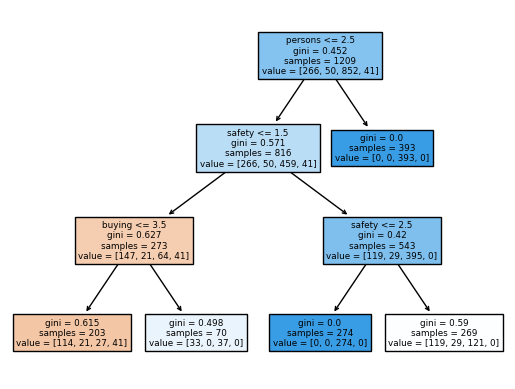

In [56]:
# plt.figure(figsi

plot_tree(clf_gini, filled=True, feature_names=X.columns);

In [57]:
(X_train['persons']<=2.5).sum()

816

In [58]:
clf_gini.max_depth

3

# 7. Decision Tree Classifier with criterion entropy

In [59]:
clf_ent = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [60]:
clf_ent.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

### Predict the Test set results with criterion entropy

In [61]:
y_pred_ent = clf_ent.predict(X_test)

In [70]:
y_pred_ent

array(['unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'acc', 'acc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'acc', 'unacc', 'unacc', 'unacc', 'acc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'acc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc',
       'unacc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'acc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc',
       'unacc', 'unacc', 'unacc', 'acc', 'unacc', 'unacc', 'unacc', 'acc',
       'acc', 'unacc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc'

### Check accuracy score with criterion entropy

In [62]:
accuracy_score(y_test, y_pred_ent)

0.7591522157996147

### Compare the train-set and test-set accuracy

### Check for overfitting and underfitting

### Visualize decision-trees

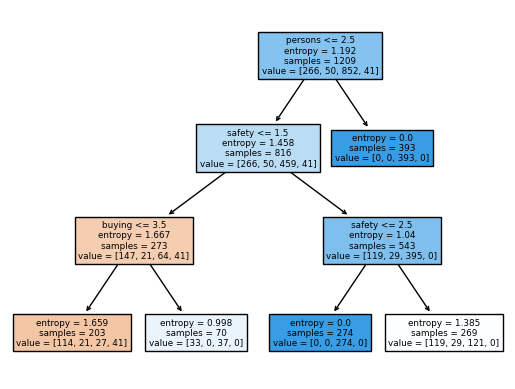

In [64]:
plot_tree(clf_ent, filled=True, feature_names=X.columns);

# 8. Confusion matrix


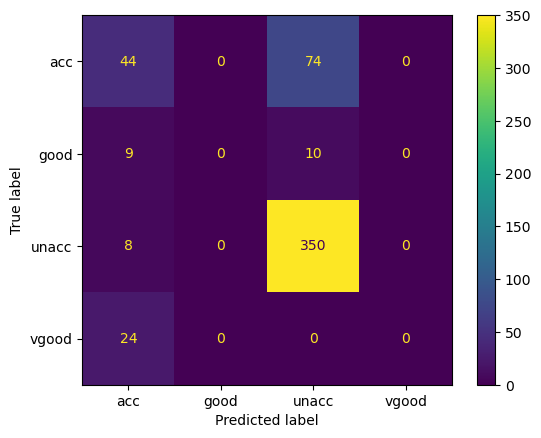

In [65]:
plot_confusion_matrix(clf_ent, X_test, y_test)

# 9. Classification Report

In [66]:
print(classification_report(y_test, y_pred_ent))

              precision    recall  f1-score   support

         acc       0.52      0.37      0.43       118
        good       0.00      0.00      0.00        19
       unacc       0.81      0.98      0.88       358
       vgood       0.00      0.00      0.00        24

    accuracy                           0.76       519
   macro avg       0.33      0.34      0.33       519
weighted avg       0.67      0.76      0.71       519



# 10. Understanding Hyperparameters

### Max Depth

### Max Leaf Nodes

In [67]:
Leaf = DecisionTreeClassifier(max_leaf_nodes= 5)

In [68]:
Leaf.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=5)

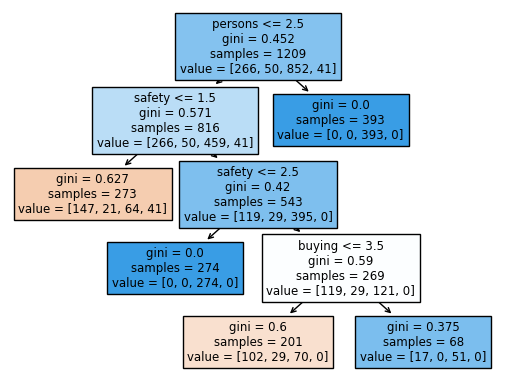

In [69]:
plot_tree(Leaf, filled=True, feature_names=X.columns);

# Part 02

# Random Forest

In [71]:
n_estimators = [64, 100, 128, 200]

max_features=[2, 3, 4]

bootstrap = [True, False]

In [72]:
param_grid = {'n_estimators':n_estimators,
             'max_features':max_features,
             'bootstrap':bootstrap}

In [73]:
RF = RandomForestClassifier()

In [76]:
grid = GridSearchCV(RF, param_grid, cv=5)

In [77]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_features': [2, 3, 4],
                         'n_estimators': [64, 100, 128, 200]})

In [78]:
grid.best_params_

{'bootstrap': False, 'max_features': 4, 'n_estimators': 100}

In [79]:
y_pred = grid.predict(X_test)

In [80]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         acc       0.90      0.88      0.89       118
        good       0.77      0.89      0.83        19
       unacc       0.97      0.98      0.98       358
       vgood       0.86      0.75      0.80        24

    accuracy                           0.94       519
   macro avg       0.88      0.88      0.87       519
weighted avg       0.94      0.94      0.94       519



In [81]:
RF_OOB = RandomForestClassifier(max_features=4, n_estimators=100, oob_score=True)

In [82]:
RF_OOB.fit(X_train, y_train)

RandomForestClassifier(max_features=4, oob_score=True)

In [83]:
RF_OOB.oob_score_

0.9520264681555004

In [84]:
1 - RF_OOB.oob_score_

0.047973531844499595